### This is a hands on code implementation of backpropagation used in neural networks. This is the file that contains the engine of the entire program.

In [2]:
import numpy as np
import math
import graphviz 
import matplotlib.pyplot as plt
import torch

Microsoft Visual C++ Redistributable is not installed, this may lead to the DLL load failure.
It can be downloaded at https://aka.ms/vs/17/release/vc_redist.x64.exe


In [3]:
class Value:
    def __init__(self, data, _children=(), _op='', _label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._label = _label
        self.grad = 0.0
        self._backward = lambda:None 

    def __repr__(self): #takes a scalar value and used for representation. (prints when value gets called)
        return f"Value(data={self.data})"

    def __add__(self, other): #__add__ is a built in method that gets called when + is used between the objects of classes.
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):  # handles int/float + Value
        return self + other
           
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)  
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):  # handles int/float * Value
        return self * other
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):  # handles int/float - Value
        return other + (-self)
    
    def __neg__(self):
        return self * -1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only accepting float and int powers."
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            # d/dx(x^n) = n * x^(n-1) * upstream_grad
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):  # self / other
        return self * (other ** -1)
    
    def __rtruediv__(self, other):  # other / self (e.g., 2 / Value)
        return other * (self ** -1)
    
    def tanh(self):
        n = self.data
        t = ((math.exp(2*n)-1)/(math.exp(2*n)+1))
        out=Value(t,(self, ),"tanh")
        def _backward():
            self.grad += (1-t**2)*out.grad
        
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad += out.data*out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()




# Create input values
a = Value(2.0, _label='a') #passes self.data = 2, label = "a", and rest are considered empty.
b = Value(-3.0, _label='b')
c = Value(10.0, _label='c')
f = Value(-2.0, _label='f')

# Forward pass
e = a * b
e._label = "e"

d = e + c
d._label = 'd'

L = d * f
L._label = 'L'

In [4]:
#checking normal integer addition.
a = Value(2.0)
a.exp()

Value(data=7.38905609893065)

In [5]:
from graphviz import Digraph


def trace(root):
    """Build a set of all nodes and edges in the graph."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    """Visualize the computation graph."""
    dot = Digraph(format='svg', graph_attr={"rankdir": "LR"})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # Create a rectangular node for each value
        dot.node(
            name=uid,
            label="{%s | data %.4f | grad %.4f}" % (n._label, n.data, n.grad),
            shape='record'
        )
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

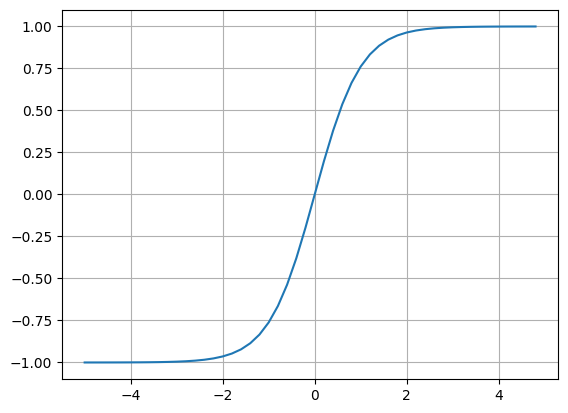

In [6]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid()

In [7]:
#inputs X1,X2
x1 = Value(2.0, _label="x1")
x2 = Value(0.0, _label="x2")
#weights 
w1 = Value(-3.0, _label="w1")
w2 = Value(1.0, _label="w2")
#bias of the neuron
b = Value(6.8813735, _label="bias")
x1w1 = x1 * w1; x1w1._label = "x1*w1"
x2w2 = x2 * w2; x2w2._label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b; n._label = "n"
o = n.tanh(); o._label = "o"
o.backward()

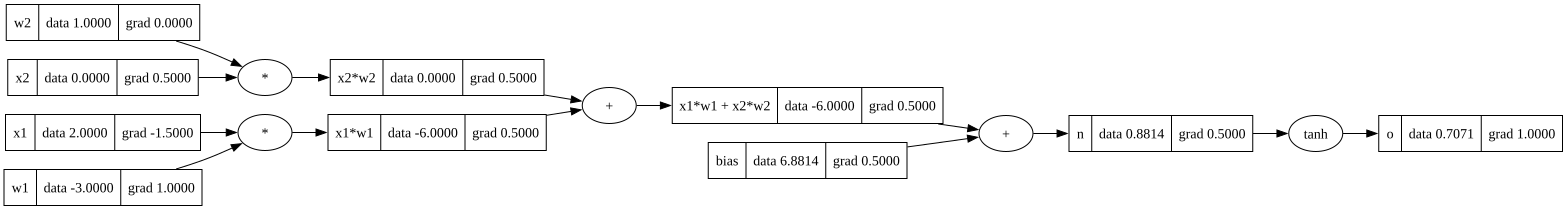

In [8]:
draw_dot(o)

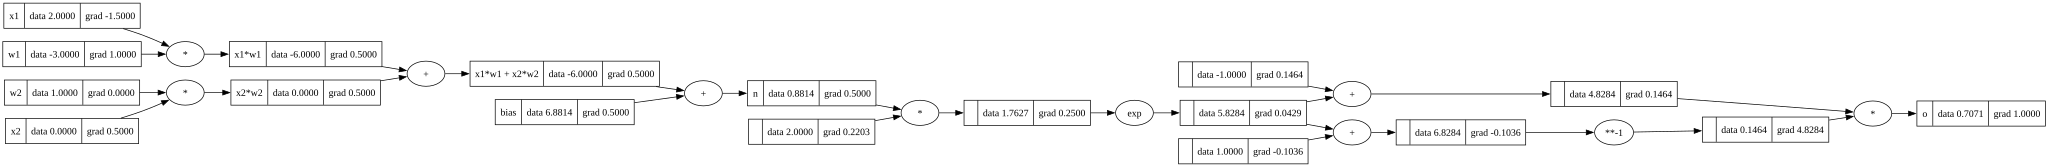

In [9]:
#inputs X1,X2
x1 = Value(2.0, _label="x1")
x2 = Value(0.0, _label="x2")
#weights 
w1 = Value(-3.0, _label="w1")
w2 = Value(1.0, _label="w2")
#bias of the neuron
b = Value(6.8813735, _label="bias")
x1w1 = x1 * w1; x1w1._label = "x1*w1"
x2w2 = x2 * w2; x2w2._label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b; n._label = "n"
e = (2*n).exp()
o = (e-1)/(e+1)
o._label = "o"
o.backward()
draw_dot(o)

In [10]:
#implementation of the same using pytorch 
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ;w2.requires_grad =True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 +b
o = torch.tanh(n)
print(o.data.item())
o.backward()
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())




0.7071066904050358
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [11]:
import random

class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1))for _ in range (nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self,x):
        #w*x+b
        act = sum((wi*xi for wi, xi in zip(self.w,x)),self.b)
        out  = act.tanh()
        return out
    def parameters(self):
        return self.w+[self.b]
    
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs = [n(x)for n in self.neurons]
        return outs[0] if len(outs)==1 else outs 
    def parameters (self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params  


class MLP:
    def __init__(self,nin,nouts):
        sz = [nin]+nouts
        self.layers = [Layer(sz[i], sz[i+1])for i in range (len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x


x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])

n(x)

Value(data=-0.12220752977589827)

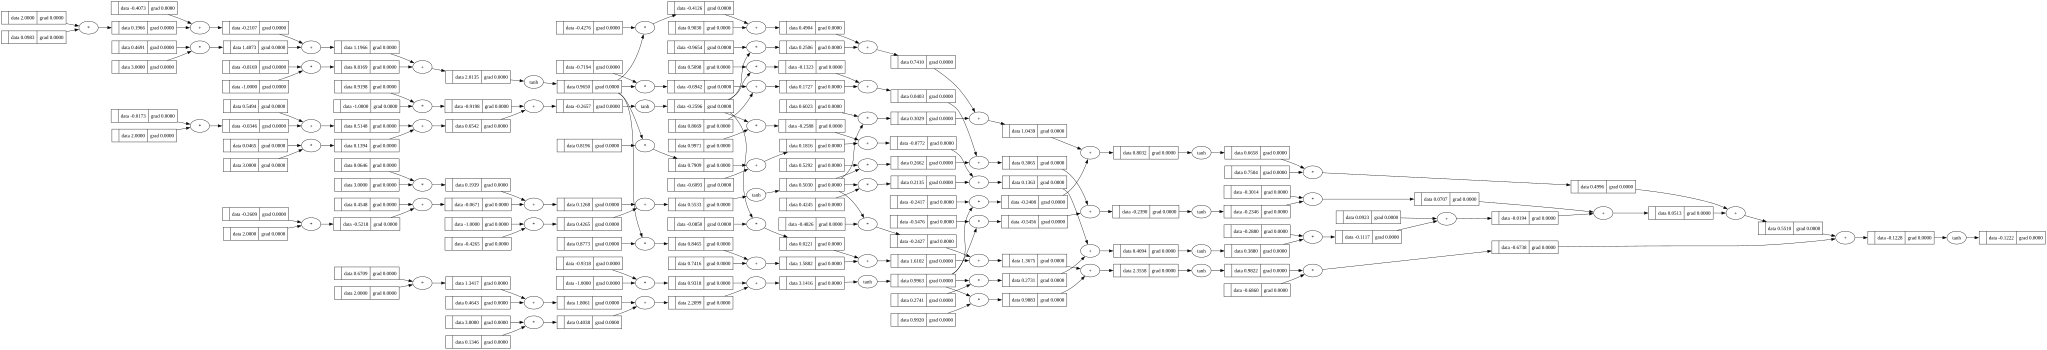

In [12]:
draw_dot(n(x))

In [13]:
xs = [[2.0,3.0,-1.0],
      [3.0,-1.0,0.5],
      [0.5,1.0,1.0],
      [1.0,1.0,-1.0]
      ]
ys = [1.0,-1.0,-1.0,1.0]
#a simple binary predictor dataset.
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.12220752977589827),
 Value(data=-0.5382603634537124),
 Value(data=-0.03833680164160096),
 Value(data=-0.03390320473036406)]

In [14]:
# Mean Squared Error loss
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss


Value(data=3.466305175672244)

In [15]:
loss.backward()

In [16]:
n.layers[0].neurons[0].w[0].grad

-0.9370018675157912

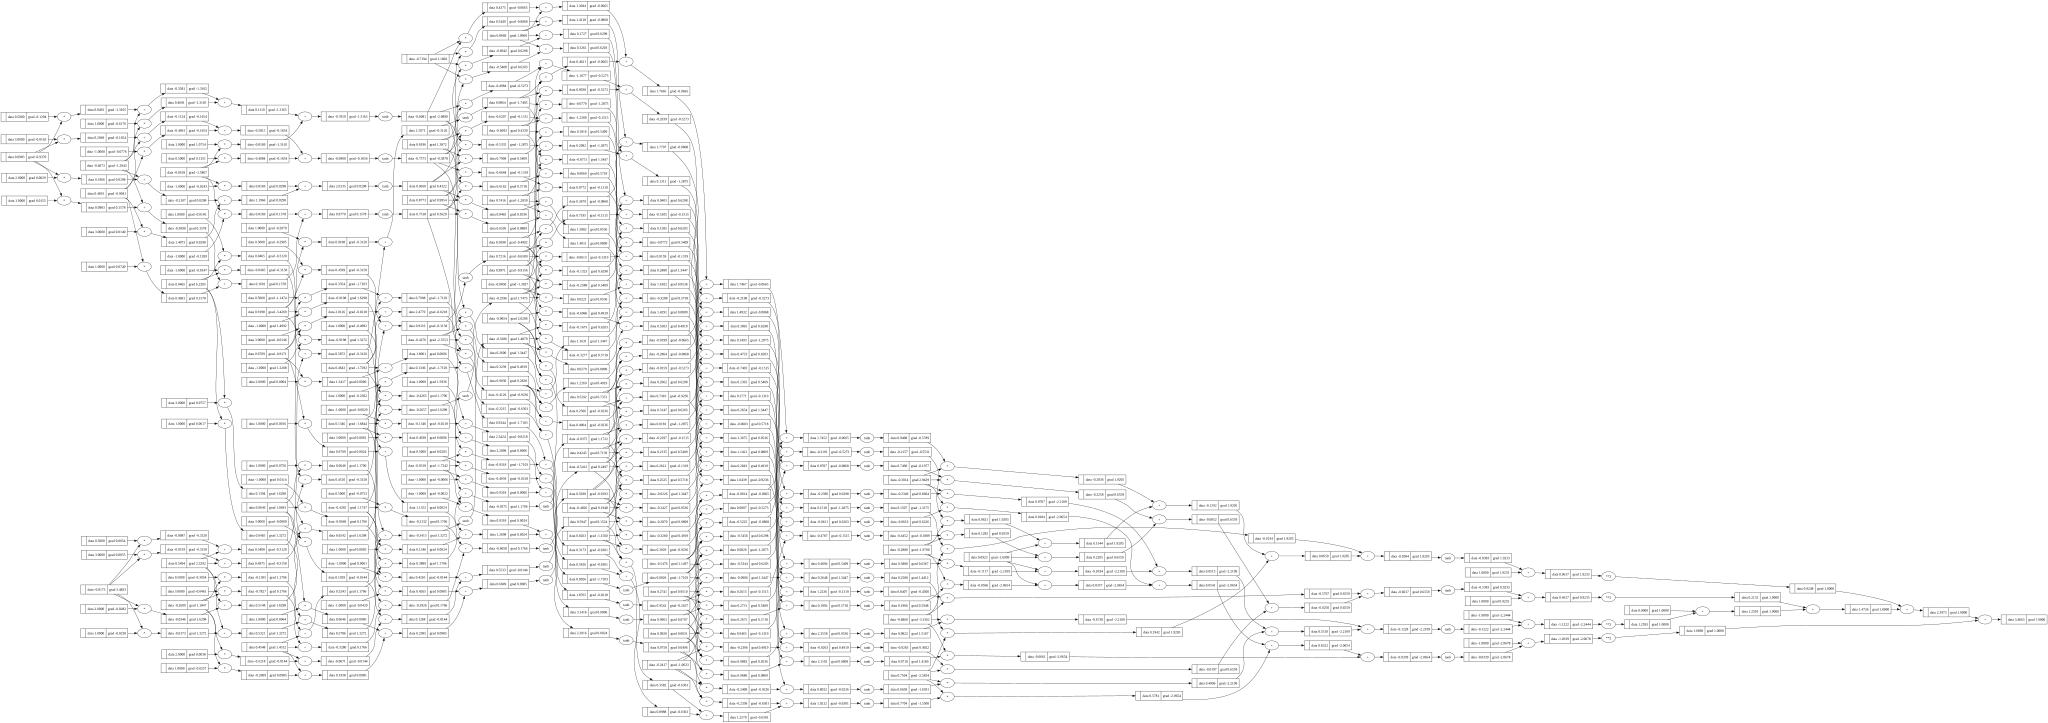

In [17]:
draw_dot(loss)